# Coverage decision table

## Scope

Phase 3 of the specification ends with a decision per protease. This notebook
joins the source audits `0_01` to `0_13` and applies the decision rule.

The decision is reported on three independent axes, because the sources answer
three different questions and a single verdict built on their sum selects
proteases by whichever question is easiest to satisfy:

* **Specificity.** Which local windows occur among the substrates a protease
  cleaves. MEROPS and PICS answer this. A cleavage-site occurrence is not a
  rate, and without a model of the library background it is not a cleavage
  probability either.
* **Quantitative kinetics.** What was measured for a given substrate. BRENDA
  provides absolute $k_{cat}/K_M$ anchors; qPISA and the quenched-fluorescence
  peptides provide relative turnover.
* **Relevance.** Whether the protease appears in the experimental control
  panel of the project, from `0_13`.

An earlier version of this notebook summed BRENDA substrates, qPISA sequences
and PICS windows into one `shape_labels` column and labelled the result
`protease_specific_model`. That column mixed occurrences with rates and
produced a verdict that reflected data availability alone.

## Conventions

A source that could not be retrieved is recorded as a blocker rather than as a
zero, so that a later run with the source restored changes the verdict. A label
without a resolvable cleavage window does not count; all counts used by the
rules are window-resolved counts.

## Inputs and outputs

Inputs: the result tables of `0_01` to `0_13`.

Outputs: `results/0_14_dataset_definition.csv` and
`results/0_14_validation_level_status.csv`.

In [1]:
import sys
from pathlib import Path

# The shared module sits one directory above the notebook; locating it by content
# keeps the notebooks working if the analysis directory is renamed or renumbered.
_cwd = Path.cwd().resolve()
_notebooks = next(p for p in [_cwd, *_cwd.parents] if (p / "_analysis_common.py").is_file())
sys.path.insert(0, str(_notebooks))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import _analysis_common as common

common.apply_style()

## Parameters

Every knob this notebook has is in the cell below: thresholds, filters, sample
sizes and seeds. Shared policy that several notebooks obey — the assay-condition
window, the minimum evidence per protease, the permutation count — lives in
`_analysis_common.py` and is imported rather than repeated, so a change there
reaches every notebook that does not override it here.

In [2]:
# Distinct window-resolved substrates required for each status. A held-out split
# needs enough distinct sequences on both sides, not merely enough observations.
MIN_FOR_SPECIFICITY_MODEL = 200
MIN_FOR_SPECIFICITY_CHECK = 30
MIN_KINETIC_SET = 30
MIN_KINETIC_ANCHORS = 3

# Sources requested by the acquisition contract that are not available.
BLOCKED_SOURCES = {
    "sabio_rk": "endpoint returns HTML instead of entry identifiers",
    "qmsp_ms_PXD009269": "supplementary tables not resolvable under the PMC AWS prefix",
    "adamts13_PMC4522773": "required supplementary XLSX not resolvable under the PMC AWS prefix",
}

In [3]:
results = common.RESULTS_ROOT
required = [
    "0_01_merops_matrices.csv",
    "0_02_serum_protease_geometry.csv",
    "0_09_brenda_coverage.csv",
    "0_06_dpp4_qpisa_coverage.csv",
    "0_05_mmp_pics_coverage.csv",
    "0_12_serum_halflife_coverage.csv",
    "0_03_hpa_abundance_coverage.csv",
    "0_13_control_panel_labels.csv",
]
for name in required:
    record = common.describe_source(results / name)
    print(f"{'ok ' if record['exists'] else 'MISSING'} {name}")
missing_inputs = [name for name in required if not (results / name).is_file()]
if missing_inputs:
    raise FileNotFoundError(f"run the earlier notebooks first: {missing_inputs}")

ok  0_01_merops_matrices.csv
ok  0_02_serum_protease_geometry.csv
ok  0_09_brenda_coverage.csv
ok  0_06_dpp4_qpisa_coverage.csv
ok  0_05_mmp_pics_coverage.csv
ok  0_12_serum_halflife_coverage.csv
ok  0_03_hpa_abundance_coverage.csv
ok  0_13_control_panel_labels.csv


In [4]:
merops_audit = pd.read_csv(results / "0_01_merops_matrices.csv")
geometry = pd.read_csv(results / "0_02_serum_protease_geometry.csv")
brenda = pd.read_csv(results / "0_09_brenda_coverage.csv")
qpisa = pd.read_csv(results / "0_06_dpp4_qpisa_coverage.csv")
pics = pd.read_csv(results / "0_05_mmp_pics_coverage.csv")
half_life = pd.read_csv(results / "0_12_serum_halflife_coverage.csv")
abundance = pd.read_csv(results / "0_03_hpa_abundance_coverage.csv")
relevance = pd.read_csv(results / "0_13_control_panel_labels.csv")

table = geometry.merge(
    merops_audit.rename(columns={"code": "merops_code"})[
        [
            "merops_code",
            "n_cleavages",
            "min_subsite_depth",
            "mean_divergence_excess",
            "median_rank_stability",
            "merops_matrix_verdict",
        ]
    ],
    on="merops_code",
    how="left",
    suffixes=("", "_audit"),
)
print(f"panel entries: {len(table)}")

panel entries: 55


## Specificity evidence

Two kinds of evidence are kept apart. The MEROPS matrix is the incumbent
specificity model and its quality comes from `0_01`. An independent
window-resolved dataset is what would be needed to replace or extend that
matrix; only PICS and qPISA provide one.

In [5]:
pics_occurrence = pics.query("measurement_type == 'cleavage_site_occurrence'")
table["pics_full_windows"] = (
    table["merops_code"]
    .map(dict(zip(pics_occurrence["merops_code"], pics_occurrence["n_full_windows"])))
    .fillna(0)
    .astype(int)
)
table["qpisa_sequences"] = (
    table["merops_code"]
    .map(dict(zip(qpisa["merops_code"], qpisa["n_unique_sequences"])))
    .fillna(0)
    .astype(int)
)
table["independent_windows"] = table["pics_full_windows"] + table["qpisa_sequences"]

matrix_usable = table["merops_matrix_verdict"].isin(["well_determined", "usable"])
table["specificity_status"] = np.select(
    [
        table["independent_windows"] >= MIN_FOR_SPECIFICITY_MODEL,
        table["independent_windows"] >= MIN_FOR_SPECIFICITY_CHECK,
        matrix_usable,
        table["n_cleavages"] >= 5,
    ],
    [
        "independent_dataset_can_replace_merops",
        "independent_dataset_can_check_merops",
        "merops_matrix_only_usable",
        "merops_matrix_only_weak",
    ],
    default="no_usable_specificity",
)
print(table["specificity_status"].value_counts().to_string())

specificity_status
merops_matrix_only_weak                   34
independent_dataset_can_replace_merops     9
merops_matrix_only_usable                  7
no_usable_specificity                      5


## Quantitative kinetics

Absolute and relative labels are counted separately. Only BRENDA provides
observations on the $k_{cat}/K_M$ scale with a resolvable window; qPISA and the
quenched-fluorescence peptides are relative to their own protocol and require a
dataset intercept in any pooled model.

In [6]:
brenda_by_code = (
    brenda.dropna(subset=["merops_codes"])
    .assign(merops_code=lambda frame: frame["merops_codes"].str.split(";"))
    .explode("merops_code")
)
brenda_by_code["merops_code"] = brenda_by_code["merops_code"].str.strip()
table = table.merge(
    brenda_by_code[["merops_code", "n_unique_window_substrates", "n_kcat_km_window"]].rename(
        columns={
            "n_unique_window_substrates": "brenda_window_substrates",
            "n_kcat_km_window": "brenda_kcat_km_windows",
        }
    ),
    on="merops_code",
    how="left",
)
for column in ["brenda_window_substrates", "brenda_kcat_km_windows"]:
    table[column] = table[column].fillna(0).astype(int)

pics_rates = pics.query("measurement_type == 'relative_quenched_fluorescence_rate'")
table["relative_rate_sequences"] = table["qpisa_sequences"] + (
    table["merops_code"]
    .map(dict(zip(pics_rates["merops_code"], pics_rates["n_unique_sequences"])))
    .fillna(0)
    .astype(int)
)

table["kinetics_status"] = np.select(
    [
        table["relative_rate_sequences"] >= MIN_KINETIC_SET,
        table["brenda_kcat_km_windows"] >= MIN_KINETIC_ANCHORS,
        (table["brenda_kcat_km_windows"] > 0) | (table["relative_rate_sequences"] > 0),
    ],
    ["relative_dataset", "absolute_anchors", "single_measurement"],
    default="no_kinetics",
)
print(table["kinetics_status"].value_counts().to_string())
print()
print(f"absolute kcat/KM observations with a resolvable window, whole panel: "
      f"{int(table['brenda_kcat_km_windows'].sum())}")

kinetics_status
no_kinetics           34
single_measurement    13
absolute_anchors       7
relative_dataset       1

absolute kcat/KM observations with a resolvable window, whole panel: 46


## Relevance to the experimental control panel

The control panel names nine MEROPS codes, of which one belongs to the audited
serum panel. The remaining panel entries are not thereby irrelevant; they are
simply not assessed by any evidence collected so far, which is what the status
records.

In [7]:
named_codes = set(relevance["merops_code"])
table["named_in_control_panel"] = table["merops_code"].isin(named_codes)
table["relevance_status"] = np.where(
    table["named_in_control_panel"],
    "named_in_control_panel",
    "serum_panel_member_not_assessed",
)
print(table["relevance_status"].value_counts().to_string())
print()
print("control-panel codes that are not in the audited serum panel:")
outside = relevance[~relevance["merops_code"].isin(set(table["merops_code"]))]
print(
    outside[["merops_code", "control_protease", "matrix_source", "n_cleavages"]].to_string(index=False)
)

relevance_status
serum_panel_member_not_assessed    54
named_in_control_panel              1

control-panel codes that are not in the audited serum panel:
merops_code    control_protease              matrix_source  n_cleavages
    A26.001 OmpT_EHEC/OmpT_EPEC    merops_pathogen_dataset           54
    M04.005    LasB_pseudolysin    merops_pathogen_dataset           70
    M04.007     GelE_coccolysin    merops_pathogen_dataset           25
    M04.009          aureolysin    merops_pathogen_dataset           24
    M10.057                ZapA           no_merops_matrix            0
    S01.017           KLK5_KLK7 merops_human_outside_serum           75
    S01.269             V8_SspA    merops_pathogen_dataset         4330
    S01.300           KLK5_KLK7 merops_human_outside_serum           43


## Blockers

In [8]:
table["blocked_sources"] = ""
table.loc[table["ec_number"].isna() | (table["ec_number"] == ""), "blocked_sources"] = (
    "no_ec_number_cannot_query_brenda_or_sabio"
)
ambiguous = table["mapping_status"].str.startswith("unresolved", na=False)
table.loc[ambiguous, "blocked_sources"] = (
    table.loc[ambiguous, "blocked_sources"] + ";ambiguous_uniprot_mapping"
).str.strip(";")

print("panel-wide blocked sources:")
for source, reason in BLOCKED_SOURCES.items():
    print(f"  {source}: {reason}")
print()
print(table["blocked_sources"].replace("", "none").value_counts().to_string())

panel-wide blocked sources:
  sabio_rk: endpoint returns HTML instead of entry identifiers
  qmsp_ms_PXD009269: supplementary tables not resolvable under the PMC AWS prefix
  adamts13_PMC4522773: required supplementary XLSX not resolvable under the PMC AWS prefix

blocked_sources
none                                                                   42
no_ec_number_cannot_query_brenda_or_sabio                               9
no_ec_number_cannot_query_brenda_or_sabio;ambiguous_uniprot_mapping     4


## Combined scope

The three axes are combined into a statement of what can be modelled, which is
narrower than any single axis suggests.

In [9]:
table["model_scope"] = np.select(
    [
        table["event_geometry"] == "non_hydrolase",
        table["event_geometry"] == "unknown",
        (table["specificity_status"] == "independent_dataset_can_replace_merops")
        & (table["kinetics_status"] == "relative_dataset"),
        table["specificity_status"] == "independent_dataset_can_replace_merops",
        table["specificity_status"] == "independent_dataset_can_check_merops",
        (table["kinetics_status"] == "absolute_anchors") & matrix_usable,
        matrix_usable,
    ],
    [
        "excluded_non_hydrolase",
        "geometry_unresolved",
        "specificity_and_relative_kinetics",
        "specificity_model_only",
        "specificity_check_only",
        "merops_feature_with_kinetic_anchors",
        "merops_feature_only",
    ],
    default="insufficient_evidence",
)
print(table["model_scope"].value_counts().to_string())
print()
print(
    table.query("model_scope not in ['insufficient_evidence', 'merops_feature_only', "
                "'excluded_non_hydrolase', 'geometry_unresolved']")[
        [
            "merops_code",
            "merops_name",
            "event_geometry",
            "n_cleavages",
            "independent_windows",
            "brenda_kcat_km_windows",
            "relative_rate_sequences",
            "specificity_status",
            "kinetics_status",
            "relevance_status",
            "model_scope",
        ]
    ]
    .sort_values("independent_windows", ascending=False)
    .to_string(index=False)
)

model_scope
insufficient_evidence                  35
specificity_model_only                  8
merops_feature_only                     6
geometry_unresolved                     3
excluded_non_hydrolase                  1
merops_feature_with_kinetic_anchors     1
specificity_and_relative_kinetics       1

merops_code                         merops_name       event_geometry  n_cleavages  independent_windows  brenda_kcat_km_windows  relative_rate_sequences                     specificity_status    kinetics_status                relevance_status                         model_scope
    S09.003 dipeptidyl-peptidase IV (eukaryote) dipeptidyl_peptidase           29                53499                       0                    53499 independent_dataset_can_replace_merops   relative_dataset serum_panel_member_not_assessed   specificity_and_relative_kinetics
    M10.003           matrix metallopeptidase-2        endopeptidase         3417                  740                       0           

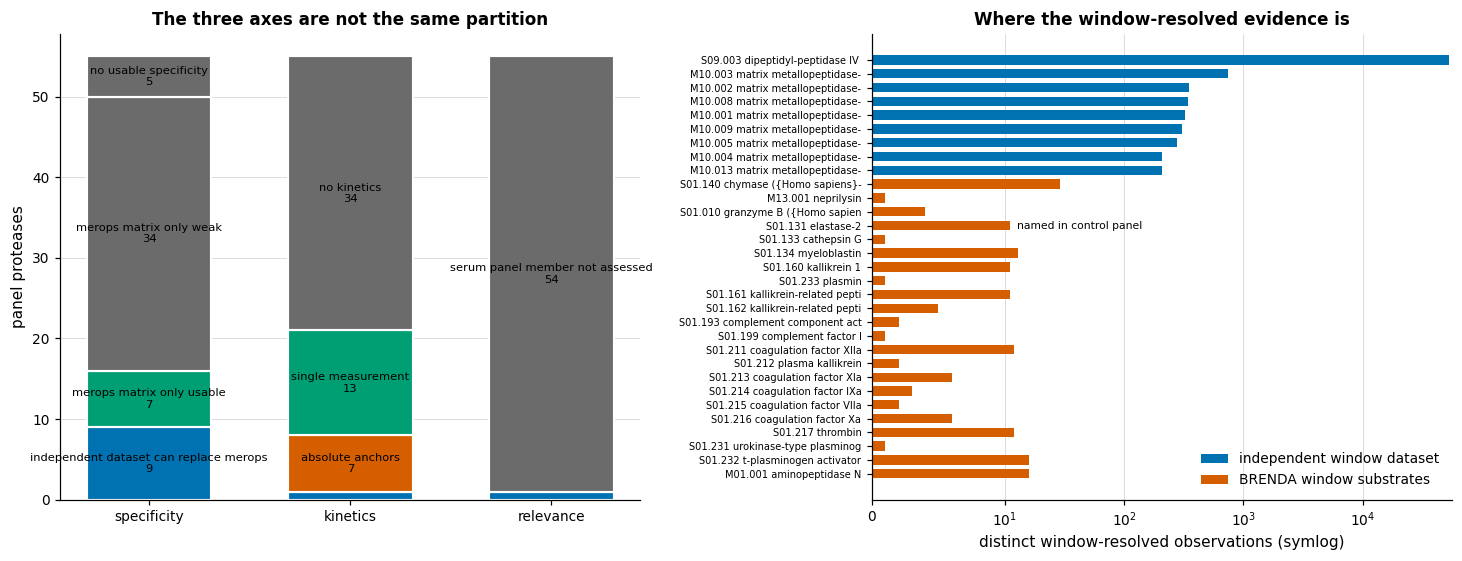

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13.4, 5.2))

ax = axes[0]
axis_names = ["specificity_status", "kinetics_status", "relevance_status"]
positions = np.arange(len(axis_names))
categories = {
    "specificity_status": [
        "independent_dataset_can_replace_merops",
        "independent_dataset_can_check_merops",
        "merops_matrix_only_usable",
        "merops_matrix_only_weak",
        "no_usable_specificity",
    ],
    "kinetics_status": ["relative_dataset", "absolute_anchors", "single_measurement", "no_kinetics"],
    "relevance_status": ["named_in_control_panel", "serum_panel_member_not_assessed"],
}
for position, axis_name in zip(positions, axis_names):
    bottom = 0
    for index, category in enumerate(categories[axis_name]):
        count = int((table[axis_name] == category).sum())
        if count == 0:
            continue
        color = (
            common.NEUTRAL
            if category.startswith(("no_", "serum_panel_member", "merops_matrix_only_weak"))
            else common.CATEGORICAL_COLORS[index % len(common.CATEGORICAL_COLORS)]
        )
        ax.bar(position, count, bottom=bottom, color=color, width=0.62, edgecolor="white", linewidth=1.4)
        if count >= 3:
            ax.text(
                position,
                bottom + count / 2,
                f"{category.replace('_', ' ')}\n{count}",
                ha="center",
                va="center",
                fontsize=7.5,
            )
        bottom += count
ax.set_xticks(positions)
ax.set_xticklabels([name.replace("_status", "") for name in axis_names])
ax.set_ylabel("panel proteases")
ax.set_title("The three axes are not the same partition")
ax.grid(axis="x", visible=False)

ax = axes[1]
labelled = table[table["independent_windows"] + table["brenda_window_substrates"] > 0].sort_values(
    "independent_windows"
)
sources = ["independent_windows", "brenda_window_substrates"]
source_labels = ["independent window dataset", "BRENDA window substrates"]
left = np.zeros(len(labelled))
for index, (column, label) in enumerate(zip(sources, source_labels)):
    ax.barh(
        range(len(labelled)),
        labelled[column],
        left=left,
        color=common.CATEGORICAL_COLORS[index],
        label=label,
        height=0.68,
    )
    left = left + labelled[column].to_numpy()
for position, (_, row) in enumerate(labelled.iterrows()):
    if row["named_in_control_panel"]:
        ax.text(left[position] * 1.15, position, "named in control panel", va="center", fontsize=7)
ax.set_yticks(range(len(labelled)))
ax.set_yticklabels([f"{row.merops_code} {row.merops_name[:24]}" for row in labelled.itertuples()], fontsize=6.5)
ax.set_xscale("symlog", linthresh=10)
ax.set_xlabel("distinct window-resolved observations (symlog)")
ax.set_title("Where the window-resolved evidence is")
ax.legend(loc="lower right")
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

## Status of each validation level

The values are derived from the joined table so that a later run with a
restored source updates them.

In [11]:
n_replace = int((table["specificity_status"] == "independent_dataset_can_replace_merops").sum())
n_relative = int((table["kinetics_status"] == "relative_dataset").sum())
n_absolute = int(table["brenda_kcat_km_windows"].sum())
n_named_in_panel = int(table["named_in_control_panel"].sum())
n_named_outside = len(relevance) - n_named_in_panel

statements = pd.DataFrame(
    [
        {
            "level": "A_merops_to_kinetics",
            "question": "does the MEROPS window score predict quantitative cleavage efficiency?",
            "status": f"testable_for_{n_relative}_protease_on_relative_labels",
            "detail": (
                f"{n_relative} protease(s) have a relative-turnover dataset large enough to fit and "
                f"hold out; {n_absolute} observations across the whole panel are on an absolute "
                "kcat/KM scale, which is not enough to calibrate one protease"
            ),
        },
        {
            "level": "A_specificity_only",
            "question": "can an independent dataset replace or check a MEROPS matrix?",
            "status": f"replaceable_for_{n_replace}_proteases",
            "detail": (
                "PICS covers nine matrix metallopeptidases and qPISA covers DPP4; no other panel "
                "entry has a window-resolved dataset independent of MEROPS"
            ),
        },
        {
            "level": "B_kinetics_to_serum_stability",
            "question": "do peptides predicted to be more susceptible degrade faster in serum?",
            "status": "rank_test_only",
            "detail": (
                f"{int(half_life.query('source == \"peplife2_human_serum\"')['n_unique_sequences'].iloc[0])} "
                "distinct sequences from PEPlife2 plus "
                f"{int(half_life.query('source == \"dramp_stability\"')['n_unique_sequences'].iloc[0])} "
                "additional from DRAMP; repeated sequences disagree by up to an order of magnitude "
                "between publications"
            ),
        },
        {
            "level": "C_cleavage_to_mic",
            "question": "does a modelled cut distribution change the predicted activity sensibly?",
            "status": "precomputed_inputs_available",
            "detail": "APEX MIC predictions exist for 305k peptides and 211k DBAASP fragments",
        },
        {
            "level": "relevance",
            "question": "are the data-rich proteases the ones the control panel names?",
            "status": "no_overlap",
            "detail": (
                f"the control panel names {len(relevance)} MEROPS codes, of which {n_named_in_panel} "
                f"belongs to the audited serum panel and {n_named_outside} do not; none of them has "
                "an independent window-resolved dataset"
            ),
        },
        {
            "level": "environment",
            "question": "how much active protease is present?",
            "status": "prior_only",
            "detail": (
                f"{int(abundance['n_with_any'].iloc[0])}/{int(abundance['n_panel_proteases'].iloc[0])} "
                "proteases have an abundance value; the two HPA methods disagree by a median of "
                f"{abundance['median_abs_log10_method_ratio'].iloc[0]:.2f} log10 units"
            ),
        },
    ]
)
print(statements.to_string(index=False))

                        level                                                                 question                                     status                                                                                                                                                                                                  detail
         A_merops_to_kinetics   does the MEROPS window score predict quantitative cleavage efficiency? testable_for_1_protease_on_relative_labels 1 protease(s) have a relative-turnover dataset large enough to fit and hold out; 46 observations across the whole panel are on an absolute kcat/KM scale, which is not enough to calibrate one protease
           A_specificity_only             can an independent dataset replace or check a MEROPS matrix?                replaceable_for_9_proteases                                                               PICS covers nine matrix metallopeptidases and qPISA covers DPP4; no other panel entry has a window-r

In [12]:
destination = common.save_result(table, "0_14_dataset_definition.csv")
common.save_result(statements, "0_14_validation_level_status.csv")
print(f"written: {destination.relative_to(common.ROOT)}")
table.sort_values("independent_windows", ascending=False).head(12)[
    [
        "merops_code",
        "merops_name",
        "specificity_status",
        "kinetics_status",
        "relevance_status",
        "model_scope",
    ]
]

written: assets/experiments/analysis/09_26/20_serum_proteolysis_calibration_max/results/0_14_dataset_definition.csv


,merops_code,merops_name,specificity_status,kinetics_status,relevance_status,model_scope
54,S09.003,dipeptidyl-peptidase IV (eukaryote),independent_dataset_can_replace_merops,relative_dataset,serum_panel_member_not_assessed,specificity_and_relative_kinetics
7,M10.003,matrix metallopeptidase-2,independent_dataset_can_replace_merops,single_measurement,serum_panel_member_not_assessed,specificity_model_only
6,M10.002,matrix metallopeptidase-8,independent_dataset_can_replace_merops,single_measurement,serum_panel_member_not_assessed,specificity_model_only
11,M10.008,matrix metallopeptidase-7,independent_dataset_can_replace_merops,single_measurement,serum_panel_member_not_assessed,specificity_model_only
5,M10.001,matrix metallopeptidase-1,independent_dataset_can_replace_merops,single_measurement,serum_panel_member_not_assessed,specificity_model_only
12,M10.009,matrix metallopeptidase-12,independent_dataset_can_replace_merops,single_measurement,serum_panel_member_not_assessed,specificity_model_only
9,M10.005,matrix metallopeptidase-3,independent_dataset_can_replace_merops,single_measurement,serum_panel_member_not_assessed,specificity_model_only
8,M10.004,matrix metallopeptidase-9,independent_dataset_can_replace_merops,single_measurement,serum_panel_member_not_assessed,specificity_model_only
13,M10.013,matrix metallopeptidase-13,independent_dataset_can_replace_merops,single_measurement,serum_panel_member_not_assessed,specificity_model_only
36,S01.192,complement component activated C1r,merops_matrix_only_weak,no_kinetics,serum_panel_member_not_assessed,insufficient_evidence
